In [3]:
import pandas as pd

flights = pd.read_csv('all_pre_departure_delays_2025.csv')
weather = pd.read_csv('weather.csv')

In [4]:
print(flights.head())
print(flights.dtypes)
print(weather.head())
print(weather.dtypes)flights['scheduled_departure'] = pd.to_datetime(flights['scheduled_departure'])
weather['datetime'] = pd.to_datetime(weather['datetime'])

   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  
0         64            NaN            NaN  
1         57            NaN            NaN  
2          7            NaN            NaN  
3         24            NaN            NaN  
4          2            NaN            NaN  
YEAR               int64
MONTH_NUM          int64
MONTH_MON            str
FLT_DATE             str
APT_ICAO             str
APT_NAME             str
STATE_NAME           str
FLT_DEP_1          int64
FLT_DEP_IFR_2    float64
DLY_ALL_PRE_2    float64
dtype: object
         

In [6]:
import pandas as pd

weather = pd.read_csv('weather.csv', decimal=',')  # sagt Pandas, dass ',' als Dezimalpunkt zu behandeln ist

# Prüfen
print(weather.dtypes)

date        str
tavg    float64
tmin    float64
tmax    float64
prcp    float64
snow    float64
wdir    float64
wspd    float64
wpgt    float64
pres    float64
tsun    float64
dtype: object


In [7]:
weather['datetime'] = pd.to_datetime(weather['date'])

In [8]:
flights['scheduled_departure'] = pd.to_datetime(flights['FLT_DATE'])

In [9]:
merged = pd.merge(
    flights, 
    weather, 
    left_on='scheduled_departure', 
    right_on='datetime', 
    how='left'
)

print(merged.head())

   YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO    APT_NAME STATE_NAME  \
0  2025          1       JAN  2025-01-01     LATI      Tirana    Albania   
1  2025          1       JAN  2025-01-01     UDYZ     Yerevan    Armenia   
2  2025          1       JAN  2025-01-01     LOWG        Graz    Austria   
3  2025          1       JAN  2025-01-01     LOWI   Innsbruck    Austria   
4  2025          1       JAN  2025-01-01     LOWK  Klagenfurt    Austria   

   FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  ... tmin tmax  prcp  snow  wdir  \
0         64            NaN            NaN  ... -4.0 -2.8   0.0   NaN   NaN   
1         57            NaN            NaN  ... -4.0 -2.8   0.0   NaN   NaN   
2          7            NaN            NaN  ... -4.0 -2.8   0.0   NaN   NaN   
3         24            NaN            NaN  ... -4.0 -2.8   0.0   NaN   NaN   
4          2            NaN            NaN  ... -4.0 -2.8   0.0   NaN   NaN   

   wspd  wpgt    pres   tsun   datetime  
0  14.7  27.8  1028.8  143

In [4]:
from pymongo import MongoClient
import pandas as pd

# Verbindung zu MongoDB
client = MongoClient('mongodb://localhost:27017/')

# Datenbank auswählen
db = client['fluege_wetter']

# Collections auswählen
flights_collection = db['flights']
weather_collection = db['weather']

# Daten abrufen und in Pandas DataFrame umwandeln
df_flights = pd.DataFrame(list(flights_collection.find()))
df_weather = pd.DataFrame(list(weather_collection.find()))

# Die ersten 5 Zeilen anzeigen
print(df_flights.head())
print(df_weather.head())

                        _id  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69bc49a6f1b1581a74809342  2025          1       JAN  2025-01-01     LATI   
1  69bc49a6f1b1581a74809343  2025          1       JAN  2025-01-01     UDYZ   
2  69bc49a6f1b1581a74809344  2025          1       JAN  2025-01-01     LOWG   
3  69bc49a6f1b1581a74809345  2025          1       JAN  2025-01-01     LOWI   
4  69bc49a6f1b1581a74809346  2025          1       JAN  2025-01-01     LOWK   

     APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  \
0      Tirana    Albania         64            NaN            NaN   
1     Yerevan    Armenia         57            NaN            NaN   
2        Graz    Austria          7            NaN            NaN   
3   Innsbruck    Austria         24            NaN            NaN   
4  Klagenfurt    Austria          2            NaN            NaN   

  scheduled_departure  
0          2025-01-01  
1          2025-01-01  
2          2025-01-01  
3          202

In [5]:
from pymongo import MongoClient
import pandas as pd

# Verbindung zu MongoDB
client = MongoClient('mongodb://localhost:27017/')

# Datenbank auswählen
db = client['fluege_wetter']

# Collections auswählen
flights_collection = db['flights']
weather_collection = db['weather']

# Daten abrufen und in Pandas DataFrame umwandeln
df_flights = pd.DataFrame(list(flights_collection.find()))
df_weather = pd.DataFrame(list(weather_collection.find()))

# Die ersten 5 Zeilen anzeigen
print(df_flights.head())
print(df_weather.head())

                        _id  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69bc49a6f1b1581a74809342  2025          1       JAN  2025-01-01     LATI   
1  69bc49a6f1b1581a74809343  2025          1       JAN  2025-01-01     UDYZ   
2  69bc49a6f1b1581a74809344  2025          1       JAN  2025-01-01     LOWG   
3  69bc49a6f1b1581a74809345  2025          1       JAN  2025-01-01     LOWI   
4  69bc49a6f1b1581a74809346  2025          1       JAN  2025-01-01     LOWK   

     APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  DLY_ALL_PRE_2  \
0      Tirana    Albania         64            NaN            NaN   
1     Yerevan    Armenia         57            NaN            NaN   
2        Graz    Austria          7            NaN            NaN   
3   Innsbruck    Austria         24            NaN            NaN   
4  Klagenfurt    Austria          2            NaN            NaN   

  scheduled_departure  
0          2025-01-01  
1          2025-01-01  
2          2025-01-01  
3          202

In [6]:
# Merge der Flugdaten mit Wetterdaten anhand des Datums
df_merged = pd.merge(
    df_flights,
    df_weather,
    left_on='scheduled_departure',  # Spalte in df_flights
    right_on='datetime',            # Spalte in df_weather
    how='left'                      # left join: alle Flüge behalten
)

# Erste 5 Zeilen prüfen
print(df_merged.head())

                      _id_x  YEAR  MONTH_NUM MONTH_MON    FLT_DATE APT_ICAO  \
0  69bc49a6f1b1581a74809342  2025          1       JAN  2025-01-01     LATI   
1  69bc49a6f1b1581a74809342  2025          1       JAN  2025-01-01     LATI   
2  69bc49a6f1b1581a74809343  2025          1       JAN  2025-01-01     UDYZ   
3  69bc49a6f1b1581a74809343  2025          1       JAN  2025-01-01     UDYZ   
4  69bc49a6f1b1581a74809344  2025          1       JAN  2025-01-01     LOWG   

  APT_NAME STATE_NAME  FLT_DEP_1  FLT_DEP_IFR_2  ...  tmin tmax prcp snow  \
0   Tirana    Albania         64            NaN  ...  -4.0 -2.8  0.0  NaN   
1   Tirana    Albania         64            NaN  ...  -4.0 -2.8  0.0  NaN   
2  Yerevan    Armenia         57            NaN  ...  -4.0 -2.8  0.0  NaN   
3  Yerevan    Armenia         57            NaN  ...  -4.0 -2.8  0.0  NaN   
4     Graz    Austria          7            NaN  ...  -4.0 -2.8  0.0  NaN   

   wdir  wspd  wpgt    pres   tsun   datetime  
0   NaN  14.7 

In [7]:
df_merged.groupby(pd.cut(df_merged['tavg'], bins=[-10,0,10,20,30]))['FLT_DEP_1'].mean()

tavg
(-10, 0]    61.506572
(0, 10]     66.588876
(10, 20]    79.858631
(20, 30]    84.492580
Name: FLT_DEP_1, dtype: float64

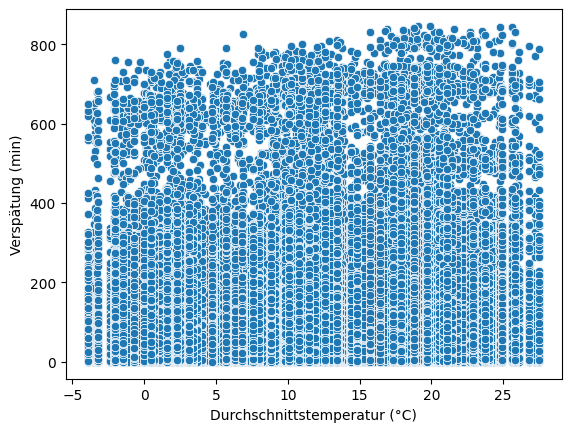

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='tavg', y='FLT_DEP_1', data=df_merged)
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Verspätung (min)")
plt.show()